
## **1. Imports**


In [10]:
!pip install pandas requests tqdm

"pip" �� ���� ����७��� ��� ���譥�
��������, �ᯮ��塞�� �ணࠬ��� ��� ������ 䠩���.


In [11]:
import os

# Option A: key already set in environment
from pathlib import Path
from dotenv import load_dotenv

_env_candidates = [Path("../.env"), Path("../eval.env"), Path("../../eval.env")]
for _p in _env_candidates:
    if _p.exists():
        load_dotenv(_p)
        break

OPENROUTER_API_KEY = os.environ.get("OPENROUTER_API_KEY", "")
assert OPENROUTER_API_KEY, "Set OPENROUTER_API_KEY in eval.env/.env"
print("OPENROUTER_API_KEY is set")

OPENROUTER_API_KEY is set


In [12]:
OPENROUTER_BASE_URL = "https://openrouter.ai/api/v1"

MODEL = "anthropic/claude-opus-4.6"   # or "anthropic/claude-opus-4.6"

# I/O
INPUT_CSV = "dataset/1_2_scene_understanding.csv"
OUTPUT_CSV = "1_2_with_answers_claude-opus-4_6.csv"
OUTPUT_JSONL = "1_2_with_answers_claude-opus-4_6_raw.jsonl"

# Column in CSV that contains the prompt/question
QUESTION_COL = "question_text"
VIEWPOINT_SCENES_COL = "file_path"  # required main image column
INSTRUCTION_SUFFIX = """Provide a brief explanation as solid text in 1–2 sentences only. Write the final answer on a separate line using only: `@YES`or `@NO`.

Limit your answer to 200 words (approximately 250–350 tokens). Avoid redundancy. Do NOT use bullet points, numbered steps, or extended reasoning."""

DIMENSION_FIELD_SCHEMA = {
    "anyOf": [
        {
            "type": "object",
            "properties": {
                "value": {"type": "number"},
                "unit": {"type": "string"},
                "source_view": {"type": "string"},
            },
            "required": ["value", "unit", "source_view"],
            "additionalProperties": False,
        },
        {"type": "null"},
    ]
}

JSON_SCHEMA = {
    "type": "object",
    "properties": {
        "reasoning_brief": {
            "type": "string",
            "description": "Very short justification, maximum 15-20 words",
        },
        "width": DIMENSION_FIELD_SCHEMA,
        "height": DIMENSION_FIELD_SCHEMA,
        "depth": DIMENSION_FIELD_SCHEMA,
    },
    "required": ["reasoning_brief", "width", "height", "depth"],
    "additionalProperties": False,
}

JSON_SCHEMA_TEXT = json.dumps(JSON_SCHEMA, ensure_ascii=False, indent=2)

INSTRUCTION_SUFFIX_JSON = f"""Return your answer strictly as a valid JSON object.

Use a field "reasoning_brief" with maximum 15 words.

Then provide the required attributes in JSON format.

For each attribute:
use "value" for the numeric value
use "unit" for the measurement unit
use "source_view" for the projection where the value is visible
if the value is not shown, return null

JSON schema (must match exactly):
{JSON_SCHEMA_TEXT}

No chain-of-thought. No step-by-step explanation. No extra text."""

JSON_RESPONSE_FORMAT = {
    "type": "json_schema",
    "json_schema": {
        "name": "scene_dimensions_answer",
        "strict": True,
        "schema": JSON_SCHEMA,
    },
}

# Generation params
MAX_TOKENS = 1000
TEMPERATURE = 0.0

## 3. OpenRouter call utilities

In [13]:
import base64
import json
import mimetypes
import time
from pathlib import Path
from typing import Any, Dict, Optional

import pandas as pd
import requests


def load_input_dataframe(input_path: str) -> pd.DataFrame:
    p = Path(input_path)
    if not p.exists():
        raise FileNotFoundError(f"Input dataset not found: {p}")

    suffix = p.suffix.lower()
    if suffix == ".csv":
        return pd.read_csv(p)
    if suffix == ".jsonl":
        return pd.read_json(p, lines=True)
    if suffix == ".json":
        try:
            return pd.read_json(p)
        except ValueError:
            return pd.read_json(p, lines=True)

    raise ValueError(f"Unsupported input format: {suffix}. Use .csv, .json or .jsonl")


def build_headers(api_key: str) -> Dict[str, str]:
    headers = {
        "Authorization": f"Bearer {api_key}",
        "Content-Type": "application/json",
    }
    return headers


def check_key_info(api_key: str) -> Dict[str, Any]:
    """GET /key - check usage/credits for the key."""
    r = requests.get(f"{OPENROUTER_BASE_URL}/key", headers=build_headers(api_key), timeout=30)
    r.raise_for_status()
    return r.json()

def build_prompt(question_text: str) -> str:
    q = "" if question_text is None else str(question_text).strip()
    return q

def normalize_image_value(v: Any) -> Optional[str]:
    if v is None:
        return None
    try:
        import pandas as _pd
        if _pd.isna(v):
            return None
    except Exception:
        pass
    s = str(v).strip().strip('"').strip("'")
    return s if s else None

def collect_image_values(*values: Any) -> list[str]:
    out: list[str] = []
    seen = set()
    for v in values:
        s = normalize_image_value(v)
        if not s:
            continue
        if s in seen:
            continue
        out.append(s)
        seen.add(s)
    return out

def is_image_ref(s: str) -> bool:
    if not s:
        return False
    return Path(s).exists()

def to_image_url(image_value: str) -> str:
    s = "" if image_value is None else str(image_value).strip().strip('"').strip("'")
    if not s:
        raise ValueError("Empty image value")
    p = Path(s)
    if not p.exists():
        raise FileNotFoundError(s)
    mime, _ = mimetypes.guess_type(p.name)
    if not mime:
        mime = "image/jpeg"
    data = p.read_bytes()
    b64 = base64.b64encode(data).decode("ascii")
    return f"data:{mime};base64,{b64}"

def call_openrouter_chat(api_key: str, prompt: str, image_values: Optional[list[str]], request_id: str | None = None, instruction_suffix: str | None = None, response_format: Optional[Dict[str, Any]] = None, reasoning: Optional[Dict[str, Any]] = None) -> dict:
    url = f"{OPENROUTER_BASE_URL}/chat/completions"

    prompt_final = build_prompt(prompt)
    content = [{"type": "text", "text": prompt_final}]
    for image_value in (image_values or []):
        if not image_value:
            continue
        if not is_image_ref(image_value):
            continue
        image_url = to_image_url(image_value)
        content.append({"type": "image_url", "image_url": {"url": image_url}})

    suffix = INSTRUCTION_SUFFIX if instruction_suffix is None else instruction_suffix
    if suffix:
        content.append({"type": "text", "text": suffix})

    payload = {
        "model": MODEL,
        "messages": [
            {
                "role": "user",
                "content": content,
            }
        ],
        "max_tokens": MAX_TOKENS,
        "temperature": TEMPERATURE,
    }

    if response_format:
        payload["response_format"] = response_format
    if reasoning:
        payload["reasoning"] = reasoning

    if request_id is not None:
        payload["metadata"] = {"request_id": request_id}

    r = requests.post(url, headers=build_headers(api_key), data=json.dumps(payload), timeout=120)
    if r.status_code >= 400:
        try:
            err = r.json()
        except Exception:
            err = {"error": {"message": r.text}}
        raise RuntimeError(f"OpenRouter error {r.status_code}: {err}")

    return r.json()



def extract_finish_reason(resp: Dict[str, Any]) -> str:
    try:
        return str(resp["choices"][0].get("finish_reason", "")).strip().lower()
    except Exception:
        return ""

def extract_content(resp: Dict[str, Any]) -> Any:
    try:
        return resp["choices"][0]["message"].get("content")
    except Exception:
        return None

def response_needs_retry(resp: Dict[str, Any]) -> bool:
    finish_reason = extract_finish_reason(resp)
    content = extract_content(resp)
    if finish_reason == "length":
        return True
    if content is None:
        return True
    if isinstance(content, str) and not content.strip():
        return True
    if isinstance(content, list) and len(content) == 0:
        return True
    return False

def call_with_retries(api_key: str, prompt: str, image_values: Optional[list[str]], request_id: str, instruction_suffix: str | None = None, response_format: Optional[Dict[str, Any]] = None, max_attempts: int = 5) -> Dict[str, Any]:
    """Retry up to max_attempts for transient HTTP errors and empty/incomplete responses."""
    if max_attempts < 1:
        raise ValueError("max_attempts must be >= 1")

    backoff = 2.0
    json_schema_mode = isinstance(response_format, dict) and response_format.get("type") == "json_schema"
    strict_reasoning_mode = False

    for attempt in range(1, max_attempts + 1):
        reasoning_cfg = {"effort": "minimal"} if (json_schema_mode and strict_reasoning_mode) else None
        try:
            resp = call_openrouter_chat(
                api_key,
                prompt,
                image_values,
                request_id=request_id,
                instruction_suffix=instruction_suffix,
                response_format=response_format,
                reasoning=reasoning_cfg,
            )
        except RuntimeError as e:
            msg = str(e)
            retriable = any(code in msg for code in [" 429:", " 502:", " 503:", " 408:"])
            if (attempt == max_attempts) or (not retriable):
                raise
            time.sleep(backoff)
            backoff *= 1.7
            continue

        if response_needs_retry(resp):
            if attempt == max_attempts:
                mode = "JSON" if json_schema_mode else "text"
                raise RuntimeError(f"{mode} response incomplete after {max_attempts} attempts")
            if json_schema_mode:
                strict_reasoning_mode = True
            time.sleep(backoff)
            backoff *= 1.7
            continue

        return resp

    raise RuntimeError("Retry loop exhausted unexpectedly")


def extract_text(resp: Dict[str, Any]) -> str:
    """choices[0].message.content"""
    c = extract_content(resp)
    return c if isinstance(c, str) else ""

def is_json_answer_type(row: Any) -> bool:
    if not hasattr(row, "get"):
        return False
    val = row.get("answer_type")
    if not isinstance(val, str):
        return False
    return val.strip().lower() == "json"

def get_instruction_suffix_for_row(row: Any) -> str:
    # For json rows, rely on strict API json_schema validation only.
    return "" if is_json_answer_type(row) else INSTRUCTION_SUFFIX

def get_response_format_for_row(row: Any) -> Optional[Dict[str, Any]]:
    return JSON_RESPONSE_FORMAT if is_json_answer_type(row) else None


In [14]:
import pandas as pd
from pathlib import Path

df = load_input_dataframe(INPUT_CSV)

def clean_path(s):
    s = str(s).strip().strip('"').strip("'")
    return s

missing = []
missing_viewpoint = []
for i, row in df.head(50).iterrows():
    image_values = collect_image_values(row.get(VIEWPOINT_SCENES_COL))
    viewpoint_value = normalize_image_value(row.get(VIEWPOINT_SCENES_COL))
    if (not viewpoint_value) or (not is_image_ref(viewpoint_value)):
        missing_viewpoint.append(i)
    for s in image_values:
        p = Path(clean_path(s))
        if not p.exists():
            missing.append((i, s))

missing[:5], len(missing), missing_viewpoint[:5], len(missing_viewpoint)


([], 0, [], 0)

In [ ]:
info = check_key_info(OPENROUTER_API_KEY)
info

## 4. Run CSV -> model answers -> save
We save:
- `OUTPUT_CSV` ? input columns + `model`, `openrouter_request_id`, `model_answer`
- `OUTPUT_JSONL` ? raw responses (useful for debugging/auditing)

=== PREVIEW: prompt_final ===
Look at the attached image.
Is wc directly connected to the guest bedroom? For this task, "direct connectivity" means that the two elements are reachable from one another either directly or through at most one intermediate node.

Answer "yes" or "no".

=== PREVIEW: image_values ===
['C:\\Users\\ritaMZ\\WebstormProjects\\thesis\\backend\\scenes\\3 double flat.jpg']

=== PREVIEW: instruction_suffix ===
Provide a brief explanation as solid text in 1–2 sentences only. Write the final answer on a separate line using only: `@YES`or `@NO`.

Limit your answer to 200 words (approximately 250–350 tokens). Avoid redundancy. Do NOT use bullet points, numbered steps, or extended reasoning.


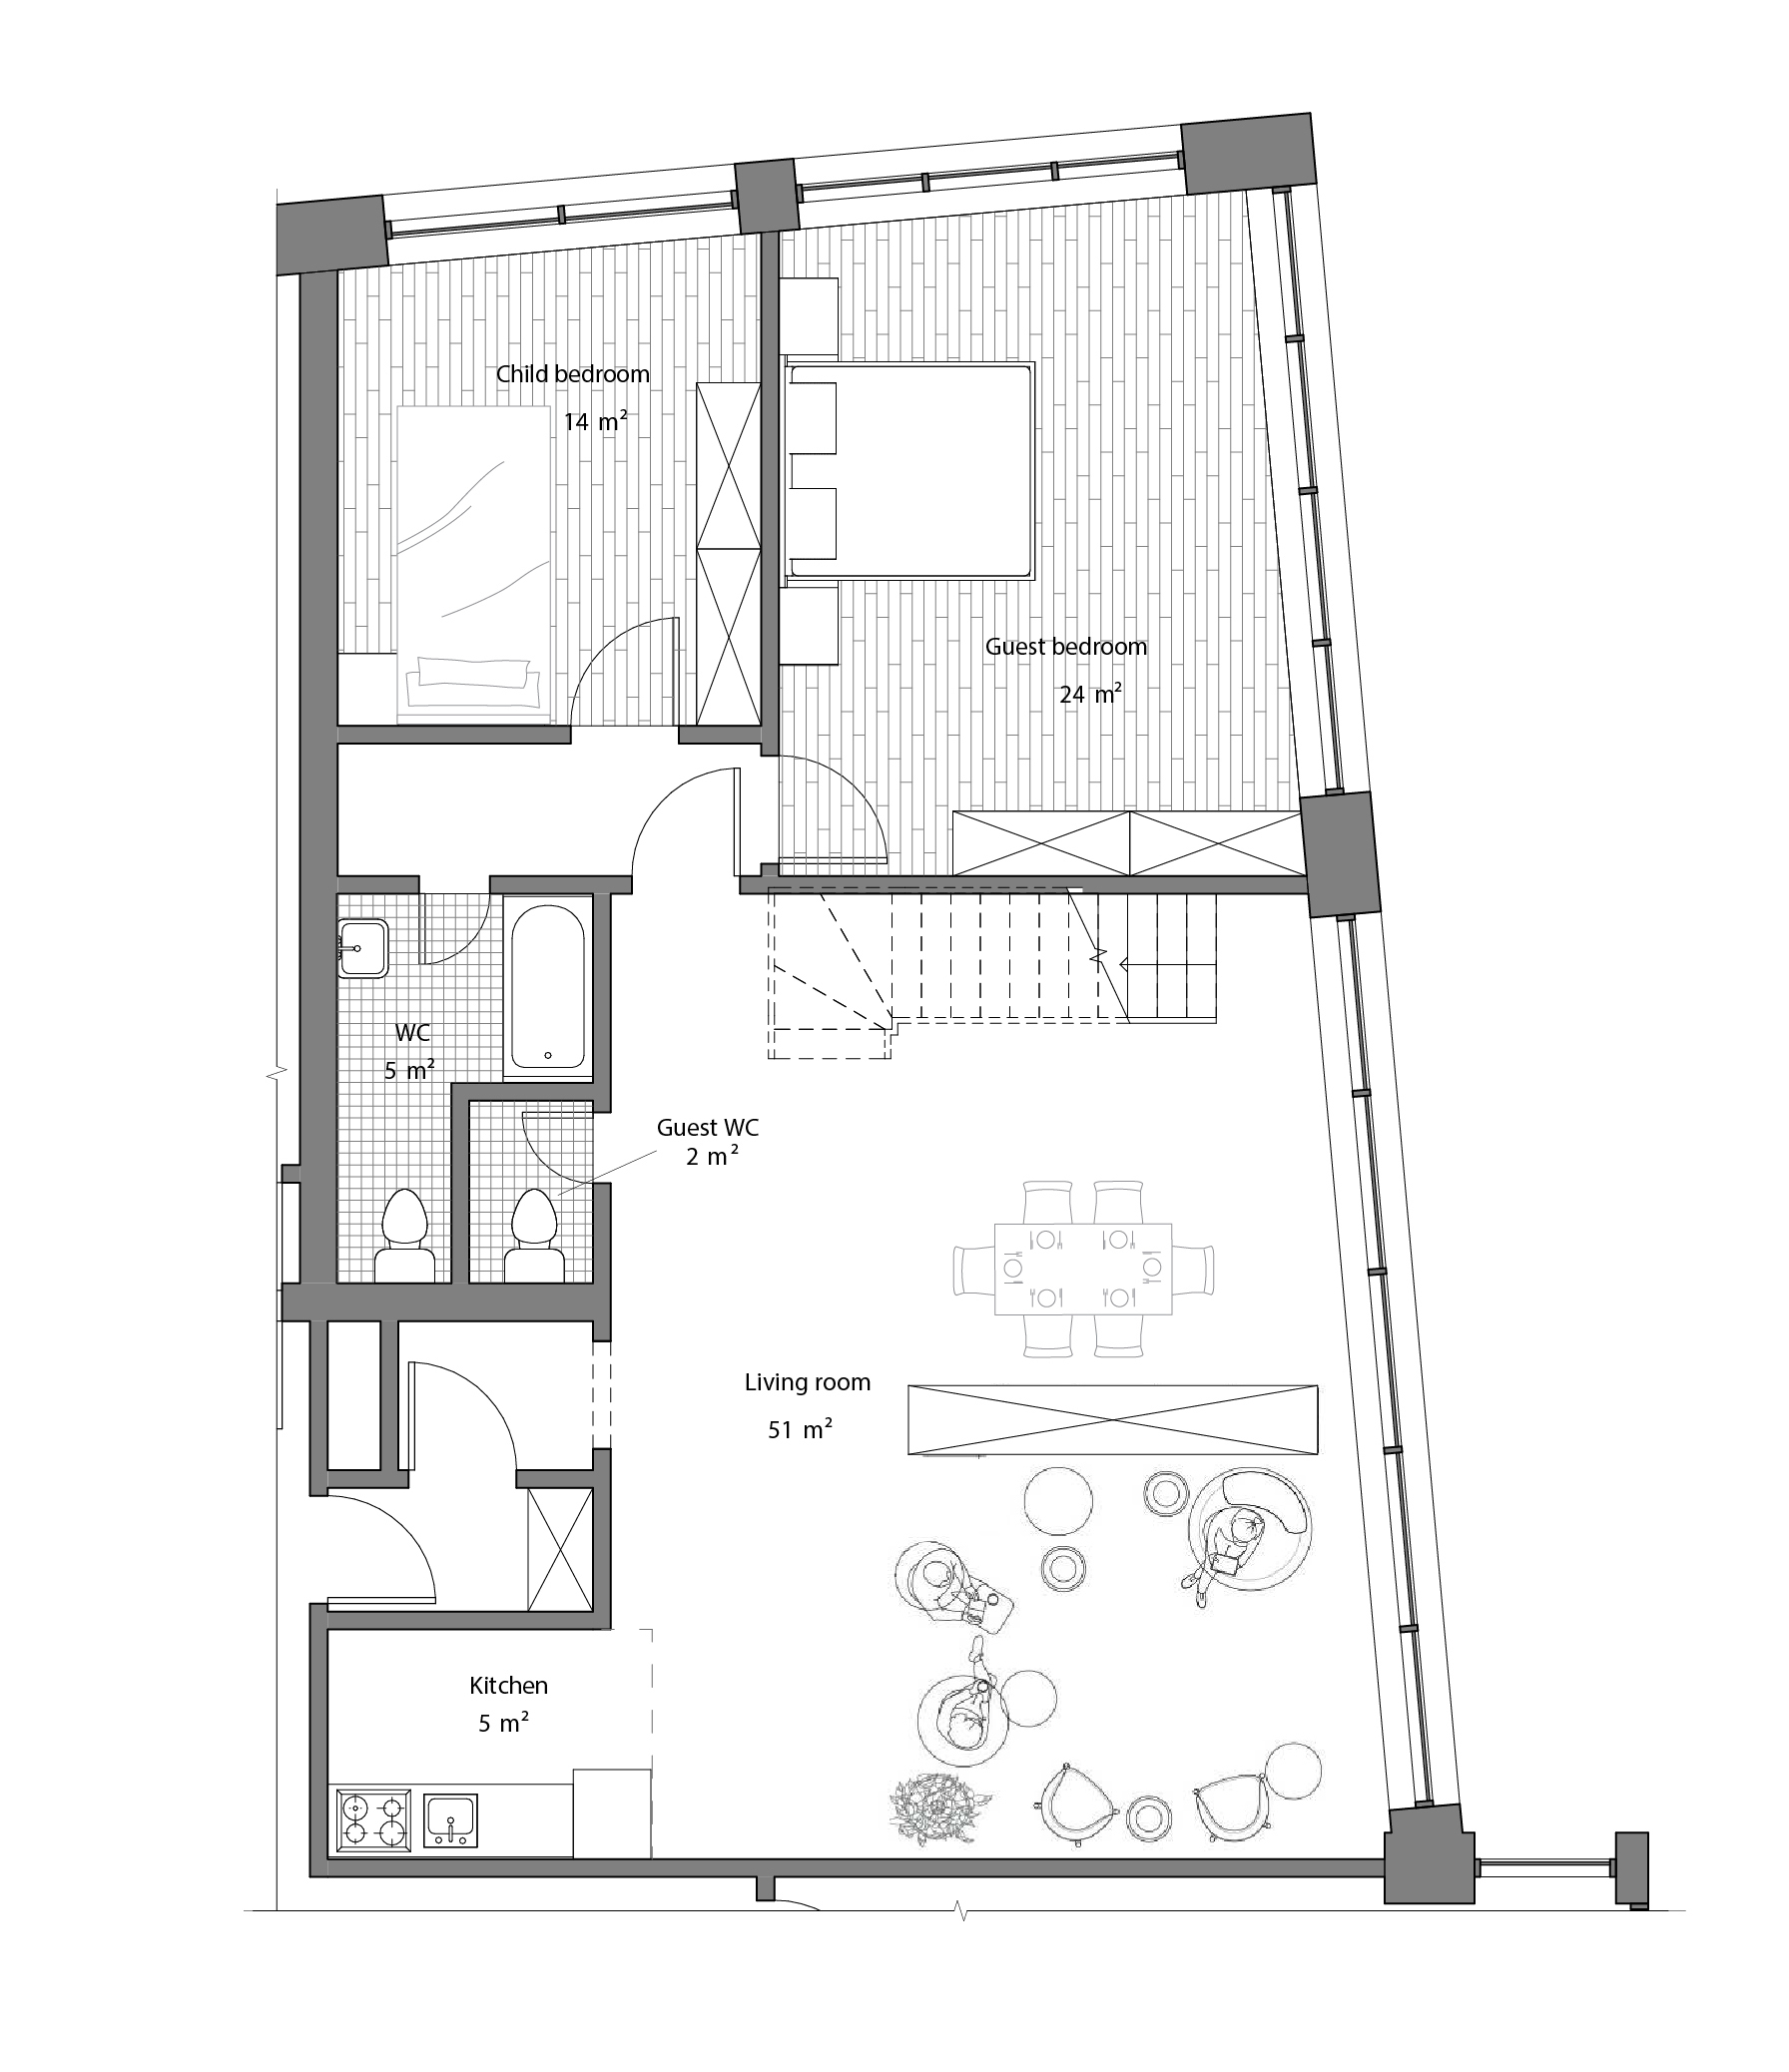

In [16]:
import pandas as pd
from pathlib import Path
from IPython.display import display, Markdown, Image

df = load_input_dataframe(INPUT_CSV)

PREVIEW_ROW = 10

row = df.iloc[PREVIEW_ROW]

question = str(row[QUESTION_COL])
image_values = collect_image_values(row.get(VIEWPOINT_SCENES_COL))

prompt_final = build_prompt(question)

print("=== PREVIEW: prompt_final ===")
print(prompt_final)
print("\n=== PREVIEW: image_values ===")
print(image_values)
print("\n=== PREVIEW: instruction_suffix ===")
print(INSTRUCTION_SUFFIX)

for idx, image_value in enumerate(image_values):
    p = Path(image_value.strip().strip('"').strip("'"))
    if p.exists():
        display(Image(filename=str(p)))
    else:
        print(f"Image {idx} file not found locally.")


In [17]:
COL_TEMPLATE = "template_id"

In [18]:
{VIEWPOINT_SCENES_COL: df[VIEWPOINT_SCENES_COL].isna().sum()} if VIEWPOINT_SCENES_COL in df.columns else {}, len(df)
missing_viewpoint = df[df[VIEWPOINT_SCENES_COL].isna()]
missing_viewpoint[[COL_TEMPLATE, QUESTION_COL, VIEWPOINT_SCENES_COL]].head(10)


,template_id,question_text,file_path


In [19]:
missing_viewpoint = df[df[VIEWPOINT_SCENES_COL].isna()]
print("Rows with NaN in viewpoint scenes path:", missing_viewpoint.index.tolist()[:50], "…")
print("Count:", len(missing_viewpoint))

missing_viewpoint[[QUESTION_COL, VIEWPOINT_SCENES_COL]].head(10)


Rows with NaN in viewpoint scenes path: [] …
Count: 0


,question_text,file_path


### Preview: 8 random questions (adjacency=5, json=3)

In [20]:
import pandas as pd
from pathlib import Path
from tqdm import tqdm
import json

PREVIEW_N = 5
PREVIEW_JSON_N = 3
PREVIEW_SEED = 60
PREVIEW_CSV = "1_2_preview_claude-opus-4_6.csv"
PREVIEW_JSONL = "1_2_preview_claude-opus-4_6_raw.jsonl"
RESUME_CSV = OUTPUT_CSV

df_preview = load_input_dataframe(INPUT_CSV)
assert QUESTION_COL in df_preview.columns, f"Input must contain column '{QUESTION_COL}'. Found: {list(df_preview.columns)}"
assert VIEWPOINT_SCENES_COL in df_preview.columns, f"Input must contain column '{VIEWPOINT_SCENES_COL}'. Found: {list(df_preview.columns)}"
assert "relation_type" in df_preview.columns, "Input must contain column 'relation_type' for adjacency filtering"
assert "answer_type" in df_preview.columns, "Input must contain column 'answer_type' for json preview filtering"

if "generated_question_id" in df_preview.columns and Path(RESUME_CSV).exists():
    done_df = pd.read_csv(RESUME_CSV)
    if "generated_question_id" in done_df.columns:
        done_ids = set(done_df["generated_question_id"].dropna())
        before = len(df_preview)
        df_preview = df_preview[~df_preview["generated_question_id"].isin(done_ids)].copy()
        print(f"Skipping {before - len(df_preview)} rows already in OUTPUT_CSV.")
    else:
        print("OUTPUT_CSV found but missing generated_question_id; skipping filter.")

adjacency_df = df_preview[df_preview["relation_type"].astype(str).str.strip().str.lower() == "adjacency"].copy()
json_df = df_preview[df_preview["answer_type"].astype(str).str.strip().str.lower() == "json"].copy()

adj_sample = adjacency_df.sample(n=min(PREVIEW_N, len(adjacency_df)), random_state=PREVIEW_SEED)
if "generated_question_id" in df_preview.columns:
    picked_ids = set(adj_sample["generated_question_id"].dropna())
    json_df = json_df[~json_df["generated_question_id"].isin(picked_ids)].copy()
json_sample = json_df.sample(n=min(PREVIEW_JSON_N, len(json_df)), random_state=PREVIEW_SEED)
sample_df = pd.concat([adj_sample, json_sample], axis=0)
print(f"Preview sample size: {len(sample_df)} (adjacency={len(adj_sample)}, json={len(json_sample)})")

preview_rows = []
with open(PREVIEW_JSONL, "w", encoding="utf-8") as fjsonl:
    for i, row in tqdm(sample_df.iterrows(), total=len(sample_df)):
        prompt = str(row[QUESTION_COL])
        image_values = collect_image_values(row.get(VIEWPOINT_SCENES_COL))
        request_id = f"preview_row_{i}"
        generated_question_id = row.get("generated_question_id")
        instruction_suffix = get_instruction_suffix_for_row(row)
        response_format = get_response_format_for_row(row)

        error_reason = ""
        text = ""
        resp = None
        viewpoint_value = normalize_image_value(row.get(VIEWPOINT_SCENES_COL))
        if (not viewpoint_value) or (not is_image_ref(viewpoint_value)):
            error_reason = "Missing viewpoint scenes path" if not viewpoint_value else f"Viewpoint scenes path not found: {viewpoint_value}"
            resp = {"error": {"message": error_reason}}
        else:
            try:
                resp = call_with_retries(
                    OPENROUTER_API_KEY,
                    prompt,
                    image_values,
                    request_id,
                    instruction_suffix=instruction_suffix,
                    response_format=response_format,
                    max_attempts=5,
                )
                text = extract_text(resp)
            except RuntimeError as e:
                error_reason = str(e)
                resp = {"error": {"message": error_reason}}

        fjsonl.write(json.dumps({"row_index": i, "request_id": request_id, "response": resp}, ensure_ascii=False) + "\n")

        preview_rows.append({
            "row_index": i,
            "generated_question_id": generated_question_id,
            "scene_id": row.get("scene_id"),
            "rule_figure_id": row.get("rule_figure_id"),
            "question_text": prompt,
            "correct_answer": row.get("correct_answer"),
            "model_answer": text,
            "openrouter_request_id": request_id,
            "error_reason": error_reason,
        })

preview_df = pd.DataFrame(preview_rows).sort_values("row_index")
preview_df.to_csv(PREVIEW_CSV, index=False)
print("Saved:", PREVIEW_CSV)
print("Saved:", PREVIEW_JSONL)
preview_df


Preview sample size: 8 (adjacency=5, json=3)


100%|██████████| 8/8 [01:14<00:00,  9.30s/it]

Saved: 1_2_preview_claude-opus-4_6.csv
Saved: 1_2_preview_claude-opus-4_6_raw.jsonl


,row_index,generated_question_id,scene_id,rule_figure_id,question_text,correct_answer,model_answer,openrouter_request_id,error_reason
0,192,192,3,None,Look at the attached image.\r\nIs wall adjacen...,None,The stove is located in the Kitchen (5 m²) in ...,preview_row_192,
1,210,210,3,None,Look at the attached image.\r\nIs plates adjac...,None,The dining table in the living room area shows...,preview_row_210,
4,214,214,3,None,Look at the attached image.\r\nIs dining table...,None,The dining table in the living room area has p...,preview_row_214,
2,302,302,22,None,Look at the attached image.\r\nIs admin 2a14 a...,None,"Looking at the floor plan, Admin 2A14 is locat...",preview_row_302,
3,339,339,22,None,Look at the attached image.\r\nIs m. staff toi...,None,"Looking at the floor plan, M. Staff Toilet 2C0...",preview_row_339,
5,575,575,15,None,In the provided set of views (plan/elevation/s...,None,"{""reasoning_brief"":""Shower curtain labeled in ...",preview_row_575,
6,578,578,15,None,In the provided set of views (plan/elevation/s...,None,"{""reasoning_brief"":""Basin visible in plan with...",preview_row_578,
7,580,580,15,None,In the provided set of views (plan/elevation/s...,None,"{""reasoning_brief"":""Vertical handrail in showe...",preview_row_580,


### Run the dataset on the model:

In [21]:
import pandas as pd
from pathlib import Path
from tqdm import tqdm
import json

FULL_INPUT = Path(INPUT_CSV)
OUTPUT_PATH = Path(OUTPUT_CSV)


def _normalize_gid_series(s: pd.Series) -> pd.Series:
    x = s.astype(str).str.strip()
    x = x.str.replace(r"\.0$", "", regex=True)  # 3.0 -> 3
    return x


def _is_empty_answer(series: pd.Series) -> pd.Series:
    s = series.fillna("").astype(str).str.strip().str.lower()
    return s.isin(["", "0", "nan", "none", "null"])


assert FULL_INPUT.exists(), f"Input dataset not found: {FULL_INPUT}"

df_full = load_input_dataframe(str(FULL_INPUT))
assert QUESTION_COL in df_full.columns, f"Input must contain column '{QUESTION_COL}'. Found: {list(df_full.columns)}"
assert VIEWPOINT_SCENES_COL in df_full.columns, f"Input must contain column '{VIEWPOINT_SCENES_COL}'. Found: {list(df_full.columns)}"
assert "generated_question_id" in df_full.columns, "Input must contain generated_question_id"

df_full["_gid_norm"] = _normalize_gid_series(df_full["generated_question_id"])

payload_cols = [
    "model_answer",
    "openrouter_request_id",
    "error_reason",
    "row_index",
    "bool_model_answer",
    "model_bool_answer",
    "parsed_json",
    "json_valid",
    "model_JSON_answer",
    "model",
]

if OUTPUT_PATH.exists():
    existing_raw = pd.read_csv(OUTPUT_PATH)
else:
    existing_raw = pd.DataFrame(columns=["generated_question_id"] + payload_cols)

for c in ["generated_question_id"] + payload_cols:
    if c not in existing_raw.columns:
        existing_raw[c] = ""

existing_raw["_gid_norm"] = _normalize_gid_series(existing_raw["generated_question_id"])
existing_raw["_has_answer"] = (~_is_empty_answer(existing_raw["model_answer"])).astype(int)

existing_best = (
    existing_raw.sort_values(["_has_answer"], ascending=False)
    .drop_duplicates(subset=["_gid_norm"], keep="first")
)

# Always rebuild OUTPUT_CSV on top of full input while preserving existing non-empty answers.
df = df_full.merge(
    existing_best[["_gid_norm"] + payload_cols],
    on="_gid_norm",
    how="left",
    suffixes=("", "_old"),
)

for c in payload_cols:
    if c not in df.columns:
        df[c] = ""

pending_mask = _is_empty_answer(df["model_answer"])
pending = df[pending_mask].copy()
print(f"Total rows in input: {len(df)}")
print(f"Rows pending model call: {len(pending)}")

answers_map = {}
request_id_map = {}
error_map = {}

with open(OUTPUT_JSONL, "w", encoding="utf-8") as fjsonl:
    for i, row in tqdm(pending.iterrows(), total=len(pending)):
        prompt = str(row[QUESTION_COL])
        image_values = collect_image_values(row.get(VIEWPOINT_SCENES_COL))
        request_id = f"row_{i}"
        gid = row.get("generated_question_id")
        gid_norm = row.get("_gid_norm")
        instruction_suffix = get_instruction_suffix_for_row(row)
        response_format = get_response_format_for_row(row)

        viewpoint_value = normalize_image_value(row.get(VIEWPOINT_SCENES_COL))
        if (not viewpoint_value) or (not is_image_ref(viewpoint_value)):
            reason = "Missing viewpoint scenes path" if not viewpoint_value else f"Viewpoint scenes path not found: {viewpoint_value}"
            fjsonl.write(json.dumps(
                {"row_index": i, "generated_question_id": gid, "request_id": request_id, "error": reason},
                ensure_ascii=False,
            ) + "\n")
            answers_map[gid_norm] = ""
            request_id_map[gid_norm] = request_id
            error_map[gid_norm] = reason
            continue

        try:
            resp = call_with_retries(
                OPENROUTER_API_KEY,
                prompt,
                image_values,
                request_id,
                instruction_suffix=instruction_suffix,
                response_format=response_format,
                max_attempts=5,
            )
            text = extract_text(resp)
            fjsonl.write(json.dumps(
                {"row_index": i, "generated_question_id": gid, "request_id": request_id, "response": resp},
                ensure_ascii=False,
            ) + "\n")

            answers_map[gid_norm] = text
            request_id_map[gid_norm] = request_id
            error_map[gid_norm] = ""
        except RuntimeError as e:
            reason = str(e)
            fjsonl.write(json.dumps(
                {"row_index": i, "generated_question_id": gid, "request_id": request_id, "error": reason},
                ensure_ascii=False,
            ) + "\n")
            answers_map[gid_norm] = ""
            request_id_map[gid_norm] = request_id
            error_map[gid_norm] = reason

# Fill only pending rows; keep existing non-empty answers untouched.
for idx, row in df[pending_mask].iterrows():
    gid_norm = row["_gid_norm"]
    if gid_norm in answers_map:
        df.at[idx, "model_answer"] = answers_map[gid_norm]
        df.at[idx, "openrouter_request_id"] = request_id_map.get(gid_norm, "")
        df.at[idx, "error_reason"] = error_map.get(gid_norm, "")
        df.at[idx, "model"] = MODEL

df_out = df.drop(columns=["_gid_norm"], errors="ignore").copy()
df_out.to_csv(OUTPUT_PATH, index=False)

remaining_empty = int(_is_empty_answer(df_out["model_answer"]).sum())
print("Saved OUTPUT_CSV:", OUTPUT_PATH)
print("Saved raw JSONL:", OUTPUT_JSONL)
print("Rows in output:", len(df_out))
print("Remaining empty model_answer:", remaining_empty)

df = df_out.copy()
df_out.head(3)


Total rows in input: 581
Rows pending model call: 581


100%|██████████| 581/581 [1:21:55<00:00,  8.46s/it]

Saved OUTPUT_CSV: 1_2_with_answers_claude-opus-4.6.csv
Saved raw JSONL: 1_2_with_answers_claude-opus-4.6_raw.jsonl
Rows in output: 581
Remaining empty model_answer: 0


,scene_id,file_path,source_column,entity_scope,template_id,layer_id,answer_type,metrics,question_text,main_entity,...,model_answer,openrouter_request_id,error_reason,row_index,bool_model_answer,model_bool_answer,parsed_json,json_valid,model_JSON_answer,model
0,3,C:\Users\ritaMZ\WebstormProjects\thesis\backen...,space_naming,spaces,14,1_2_1,bool,"Accuracy, F1 score, Validity",Look at the attached image.\r\nIs guest bedroo...,child bedroom,...,The child bedroom and guest bedroom appear to ...,row_0,,NaN,NaN,NaN,NaN,NaN,NaN,anthropic/claude-opus-4.6
1,3,C:\Users\ritaMZ\WebstormProjects\thesis\backen...,space_naming,spaces,14,1_2_1,bool,"Accuracy, F1 score, Validity",Look at the attached image.\r\nIs living room ...,child bedroom,...,The living room connects to a hallway/corridor...,row_1,,NaN,NaN,NaN,NaN,NaN,NaN,anthropic/claude-opus-4.6
2,3,C:\Users\ritaMZ\WebstormProjects\thesis\backen...,space_naming,spaces,14,1_2_1,bool,"Accuracy, F1 score, Validity",Look at the attached image.\r\nIs wc directly ...,child bedroom,...,The WC appears to connect to a hallway/corrido...,row_2,,NaN,NaN,NaN,NaN,NaN,NaN,anthropic/claude-opus-4.6


### Sanity check:

In [22]:
import numpy as np
import pandas as pd
from pathlib import Path

# Use in-memory df if available; otherwise load from OUTPUT_CSV.
if "df" in globals() and isinstance(df, pd.DataFrame) and "model_answer" in df.columns:
    df_check = df.copy()
elif "OUTPUT_CSV" in globals() and Path(OUTPUT_CSV).exists():
    df_check = pd.read_csv(OUTPUT_CSV)
else:
    raise RuntimeError("No dataframe found. Run '### Run the dataset on the model:' first or ensure OUTPUT_CSV exists.")

if "model_answer" not in df_check.columns:
    raise KeyError(f"Column 'model_answer' not found. Available columns: {list(df_check.columns)}")

lens = df_check["model_answer"].fillna("").astype(str).map(len)
print("Rows:", len(df_check))
print("Empty answers:", int((lens == 0).sum()))
print("Median length:", int(np.median(lens)) if len(lens) else 0)
print("P90 length:", int(np.quantile(lens, 0.9)) if len(lens) else 0)



Rows: 581
Empty answers: 0
Median length: 260
P90 length: 481


# 5. Metrics

### Extract Yes/No answers:

In [23]:
import pandas as pd
import re

INPUT = OUTPUT_CSV

df = pd.read_csv(INPUT)

def extract_yes_no(text: str) -> str:
    s = "" if pd.isna(text) else str(text)
    # Find explicit @YES/@NO marker, prefer the last one if multiple
    matches = re.findall(r"@\s*(YES|NO)\b", s, flags=re.IGNORECASE)
    if not matches:
        return ""
    return matches[-1].lower()

df["bool_model_answer"] = df["model_answer"].apply(extract_yes_no)

df.to_csv(INPUT, index=False)
print("Updated:", INPUT)
df[["model_answer", "bool_model_answer"]].head()


Updated: 1_2_with_answers_claude-opus-4.6.csv


,model_answer,bool_model_answer
0,The child bedroom and guest bedroom appear to ...,yes
1,The living room connects to a hallway/corridor...,yes
2,The WC appears to connect to a hallway/corrido...,yes
3,The public zone includes the living room area....,yes
4,The child bedroom opens into a hallway/corrido...,yes


### JSON extraction

In [24]:
import re
import json
import pandas as pd

def extract_json_from_text(text: str):
    # Extract the first valid JSON object from mixed text.
    if text is None or (isinstance(text, float) and pd.isna(text)):
        return None

    s = str(text).strip()
    if not s:
        return None

    # Try direct parse first
    try:
        obj = json.loads(s)
        return obj if isinstance(obj, dict) else None
    except Exception:
        pass

    # Fallback: take content between first '{' and last '}'
    first = s.find("{")
    last = s.rfind("}")
    if first == -1 or last == -1 or last <= first:
        return None

    candidate = s[first:last + 1]

    try:
        obj = json.loads(candidate)
        return obj if isinstance(obj, dict) else None
    except Exception:
        # Try regex fallback
        m = re.search(r"\{.*\}", candidate, flags=re.DOTALL)
        if not m:
            return None
        try:
            obj = json.loads(m.group(0))
            return obj if isinstance(obj, dict) else None
        except Exception:
            return None


# Apply only to multi_view_dimensions + json rows
if "relation_type" in df.columns and "answer_type" in df.columns:
    mask = (
        df["relation_type"].fillna("").astype(str).str.strip() == "multi_view_dimensions"
    ) & (
        df["answer_type"].fillna("").astype(str).str.strip() == "json"
    )

    if "model_JSON_answer" not in df.columns:
        df["model_JSON_answer"] = ""
    df["parsed_json"] = None
    df.loc[mask, "parsed_json"] = df.loc[mask, "model_answer"].apply(extract_json_from_text)

    df["json_valid"] = 0
    df.loc[mask, "json_valid"] = df.loc[mask, "parsed_json"].apply(
        lambda x: 1 if isinstance(x, dict) else 0
    )

    # Clear binary answer for JSON-based multi-view questions
    if "bool_model_answer" in df.columns:
        df.loc[mask, "bool_model_answer"] = ""

    # Store extracted JSON as a compact string for CSV export
    df.loc[mask, "model_JSON_answer"] = df.loc[mask, "parsed_json"].apply(
        lambda x: json.dumps(x, ensure_ascii=False) if isinstance(x, dict) else ""
    )

else:
    df["parsed_json"] = None
    df["json_valid"] = 0

OUT_CSV = OUTPUT_CSV
df.to_csv(OUT_CSV, index=False)
print("Saved:", OUT_CSV)
df[["relation_type", "answer_type", "model_answer", "model_JSON_answer", "json_valid"]].head()


Saved: 1_2_with_answers_claude-opus-4.6.csv


C:\Users\ritaMZ\AppData\Local\Temp\ipykernel_41168\4280686328.py:67: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['{"reasoning_brief": "Double door visible in plan view with two 755mm leaves. Height 2032mm from section. Depth not annotated.", "width": {"value": 755, "unit": "mm", "source_view": "plan"}, "height": {"value": 2032, "unit": "mm", "source_view": "section"}, "depth": null}'
 '{"reasoning_brief": "Door to Pediatric WTS & MSRS: plan shows 915mm width, section shows 2032mm height and 784mm is another door. Depth not annotated.", "width": {"value": 915, "unit": "mm", "source_view": "plan"}, "height": {"value": 2032, "unit": "mm", "source_view": "section"}, "depth": null}'
 '{"reasoning_brief": "Double door visible in plan view with two leaves of 830mm each. Height 2032mm from section 1. Depth not annotated.", "width": {"value": 830, "unit": "mm", "source_view": "plan"}, "height": {"value": 2032,

,relation_type,answer_type,model_answer,model_JSON_answer,json_valid
0,connectivity,bool,The child bedroom and guest bedroom appear to ...,NaN,0
1,connectivity,bool,The living room connects to a hallway/corridor...,NaN,0
2,connectivity,bool,The WC appears to connect to a hallway/corrido...,NaN,0
3,connectivity,bool,The public zone includes the living room area....,NaN,0
4,connectivity,bool,The child bedroom opens into a hallway/corrido...,NaN,0


### F1&Accuracy

In [26]:
import pandas as pd
import re

# INPUT = "output_with_answers_recovered.csv"
INPUT = OUTPUT_CSV
# INPUT = "1_1_1_Eval_Claude_Opus_1.csv"

COL_TEMPLATE = "template_id"
COL_GT = "ground_truth_answer"
COL_PRED = "model_answer"

df = pd.read_csv(INPUT)

def normalize_text(s: str) -> str:
    s = "" if pd.isna(s) else str(s)
    s = s.lower().strip()
    s = re.sub(r"[^\w\s]", " ", s, flags=re.UNICODE)
    s = re.sub(r"\s+", " ", s).strip()
    return s

def normalize_label(s: str) -> str:
    t = normalize_text(s)
    if t in {"yes", "true"}:
        return "yes"
    if t in {"no", "false"}:
        return "no"
    return t

def contains_whole_word(text: str, word: str) -> bool:
    if not word:
        return False
    pattern = r"(?:^|\s)" + re.escape(word) + r"(?:$|\s)"
    return re.search(pattern, text) is not None

df["gt_norm"] = df[COL_GT].apply(normalize_label)
df["pred_norm_text"] = df[COL_PRED].apply(normalize_text)

def predicted_label_from_text(pred_text: str, gt_label: str) -> str:
    return gt_label if contains_whole_word(pred_text, gt_label) else ""

df["pred_label"] = [
    predicted_label_from_text(p, g)
    for p, g in zip(df["pred_norm_text"], df["gt_norm"])
]

# correctness
df["is_correct"] = df["pred_label"] == df["gt_norm"]

# ---- metrics per each template_id ----
def group_metrics(g: pd.DataFrame) -> pd.Series:
    n = len(g)
    acc = g["is_correct"].mean() if n else 0.0

    labels = sorted(set(g["gt_norm"].unique()) | set(g["pred_label"].unique()))
    labels = [lab for lab in labels if lab != ""]  # remove empty

    # F1:
    # - If only yes/no in GT -> binary F1 (positive=yes)
    # - Otherwise, macro F1 by GT classes (ignoring empty class)
    gt_set = set(g["gt_norm"].unique())
    if gt_set.issubset({"yes", "no"}):
        y_true = g["gt_norm"].tolist()
        y_pred = [("yes" if x == "yes" else "no") if x in {"yes", "no"} else "no" for x in g["pred_label"].tolist()]
        # F1 positive=yes
        tp = sum((t == "yes") and (p == "yes") for t, p in zip(y_true, y_pred))
        fp = sum((t != "yes") and (p == "yes") for t, p in zip(y_true, y_pred))
        fn = sum((t == "yes") and (p != "yes") for t, p in zip(y_true, y_pred))
        precision = tp / (tp + fp) if (tp + fp) else 0.0
        recall = tp / (tp + fn) if (tp + fn) else 0.0
        f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) else 0.0
        f1_type = "binary(yes)"
    else:
        # macro F1 per GT classes
        y_true = g["gt_norm"].tolist()
        y_pred = g["pred_label"].tolist()

        f1s = []
        for lab in sorted(gt_set):
            tp = sum((t == lab) and (p == lab) for t, p in zip(y_true, y_pred))
            fp = sum((t != lab) and (p == lab) for t, p in zip(y_true, y_pred))
            fn = sum((t == lab) and (p != lab) for t, p in zip(y_true, y_pred))
            precision = tp / (tp + fp) if (tp + fp) else 0.0
            recall = tp / (tp + fn) if (tp + fn) else 0.0
            f1_lab = (2 * precision * recall / (precision + recall)) if (precision + recall) else 0.0
            f1s.append(f1_lab)
        f1 = sum(f1s) / len(f1s) if f1s else 0.0
        f1_type = "macro(GT-classes)"

    return pd.Series({
        "n": n,
        "accuracy": acc,
        "f1": f1,
        "f1_type": f1_type,
    })

rows = []
for template_id, g in df.groupby(COL_TEMPLATE, dropna=False):
    m = group_metrics(g)  # Series: n, accuracy, f1, f1_type
    m[COL_TEMPLATE] = template_id
    rows.append(m)

report = pd.DataFrame(rows).sort_values(COL_TEMPLATE).reset_index(drop=True)
report


,n,accuracy,f1,f1_type,template_id
0,20,0.000000,0.000000,macro(GT-classes),11
1,155,0.787097,0.945813,binary(yes),14
2,203,0.674877,0.925373,binary(yes),17
3,187,0.577540,0.900662,binary(yes),23
4,16,0.750000,0.857143,binary(yes),24
